In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Pull daily data for SPY and RSP around August 24 2015
tickers = ["SPY", "RSP"]
data = yf.download(tickers, start="2015-08-01", end="2015-09-15", auto_adjust=True)

# We want closing prices
prices = data["Close"]
print(prices.head(10))
print(prices.tail(10))

[*********************100%***********************]  2 of 2 completed

Ticker            RSP         SPY
Date                             
2015-08-03  66.842567  175.360046
2015-08-04  66.767593  175.017365
2015-08-05  67.000824  175.594193
2015-08-06  66.551079  174.156464
2015-08-07  66.434479  173.821991
2015-08-10  67.375580  176.012070
2015-08-11  66.817566  174.423874
2015-08-12  66.934181  174.632858
2015-08-13  66.825912  174.415543
2015-08-14  67.092392  175.050827
Ticker            RSP         SPY
Date                             
2015-08-31  63.436333  165.229156
2015-09-01  61.629086  160.297501
2015-09-02  62.611824  163.340057
2015-09-03  62.878334  163.457123
2015-09-04  61.920578  160.982895
2015-09-08  63.486282  165.028519
2015-09-09  62.678455  162.821854
2015-09-10  62.903290  163.707870
2015-09-11  63.144836  164.451752
2015-09-14  62.878334  163.841553


In [4]:
# Normalize both to 100 at the start so we can compare performance
normalized = prices / prices.iloc[0] * 100
print(normalized.head(10))

Ticker             RSP         SPY
Date                              
2015-08-03  100.000000  100.000000
2015-08-04   99.887835   99.804584
2015-08-05  100.236760  100.133523
2015-08-06   99.563918   99.313651
2015-08-07   99.389478   99.122916
2015-08-10  100.797415  100.371820
2015-08-11   99.962596   99.466143
2015-08-12  100.137059   99.585317
2015-08-13   99.975083   99.461392
2015-08-14  100.373751   99.823666


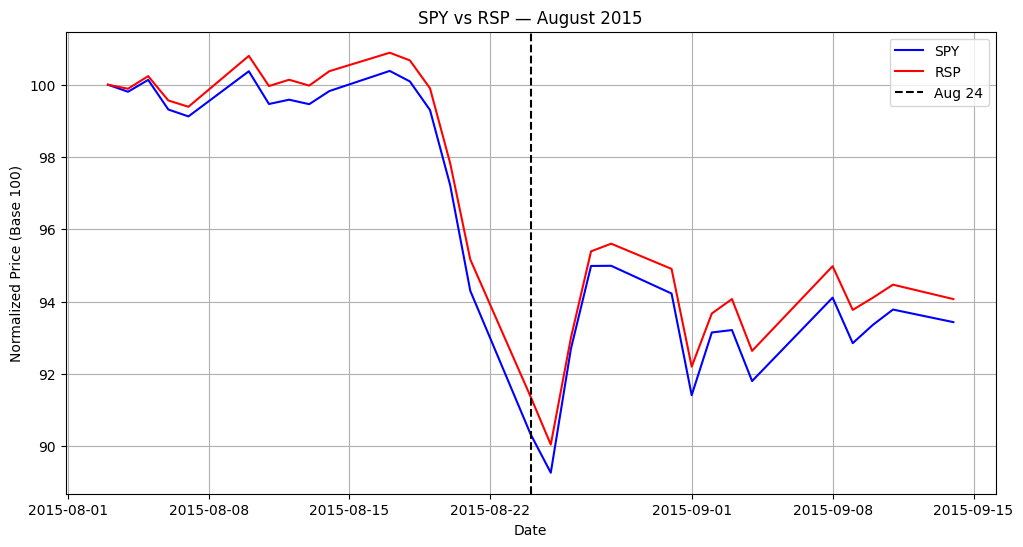

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(normalized.index, normalized["SPY"], label="SPY", color="blue")
plt.plot(normalized.index, normalized["RSP"], label="RSP", color="red")
plt.axvline(pd.Timestamp("2015-08-24"), color="black", linestyle="--", label="Aug 24")
plt.title("SPY vs RSP — August 2015")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base 100)")
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


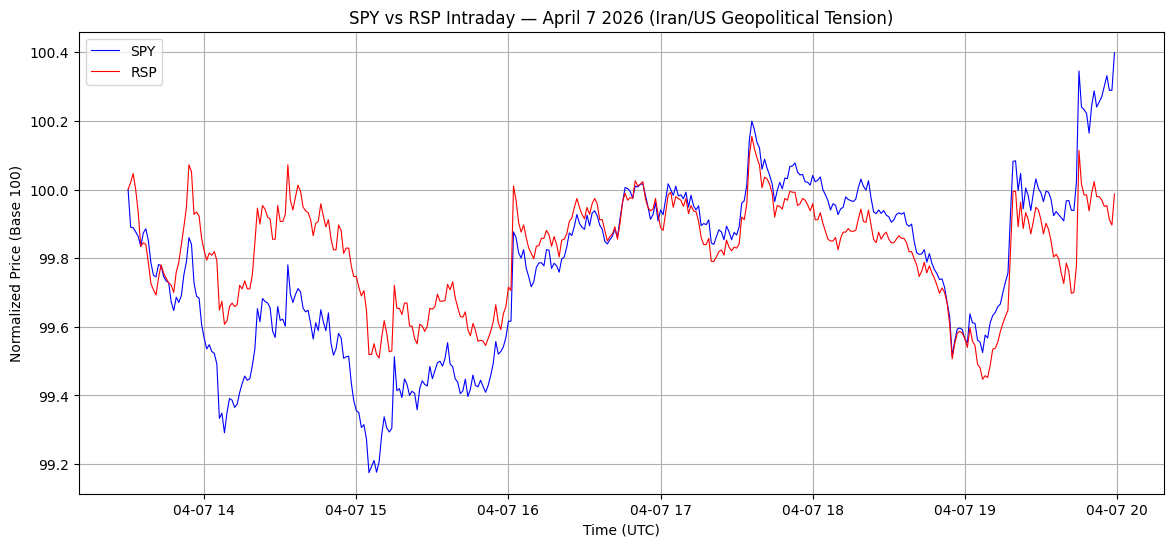

SPY intraday range: 651.22 to 659.26
RSP intraday range: 192.44 to 193.81


In [36]:
spy_5d = yf.download(
    tickers="SPY",
    period="5d",
    interval="1m",
    auto_adjust=True
)
rsp_5d = yf.download(
    tickers="RSP",
    period="5d",
    interval="1m",
    auto_adjust=True
)

# Extract April 7 for both ETFs
spy_apr7 = spy_5d["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]
rsp_apr7 = rsp_5d["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]

# Extract close prices as Series
spy_close = spy_apr7[("Close", "SPY")]
rsp_close = rsp_apr7[("Close", "RSP")]

# Normalize to 100 at open
spy_norm = spy_close / spy_close.iloc[0] * 100
rsp_norm = rsp_close / rsp_close.iloc[0] * 100

# Plot
plt.figure(figsize=(14, 6))
plt.plot(spy_norm.index, spy_norm, label="SPY", color="blue", linewidth=0.8)
plt.plot(rsp_norm.index, rsp_norm, label="RSP", color="red", linewidth=0.8)
plt.title("SPY vs RSP Intraday — April 7 2026 (Iran/US Geopolitical Tension)")
plt.xlabel("Time (UTC)")
plt.ylabel("Normalized Price (Base 100)")
plt.legend()
plt.grid(True)
plt.show()

print(f"SPY intraday range: {spy_close.min():.2f} to {spy_close.max():.2f}")
print(f"RSP intraday range: {rsp_close.min():.2f} to {rsp_close.max():.2f}")

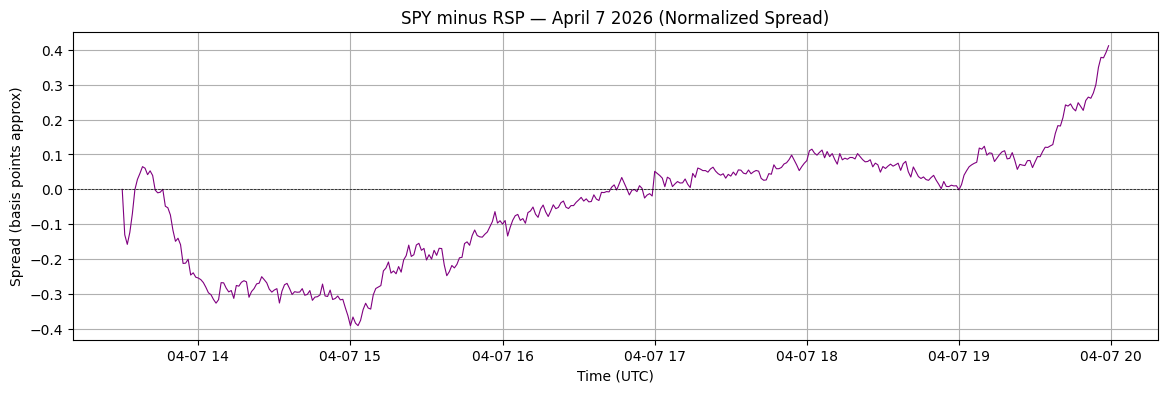

Max spread: 0.412
Min spread: -0.391
Mean spread: -0.048
Std deviation: 0.164


In [37]:
# Calculate the difference between SPY and RSP normalized prices
spread = spy_norm - rsp_norm

plt.figure(figsize=(14, 4))
plt.plot(spread.index, spread, color="purple", linewidth=0.8)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
plt.title("SPY minus RSP — April 7 2026 (Normalized Spread)")
plt.xlabel("Time (UTC)")
plt.ylabel("Spread (basis points approx)")
plt.grid(True)
plt.show()

print(f"Max spread: {spread.max():.3f}")
print(f"Min spread: {spread.min():.3f}")
print(f"Mean spread: {spread.mean():.3f}")
print(f"Std deviation: {spread.std():.3f}")

In [38]:
# Print the statistics
print(f"Max spread: {spread.max():.3f}")
print(f"Min spread: {spread.min():.3f}")
print(f"Mean spread: {spread.mean():.3f}")
print(f"Std deviation: {spread.std():.3f}")
print(f"Range: {spread.max() - spread.min():.3f}")

Max spread: 0.412
Min spread: -0.391
Mean spread: -0.048
Std deviation: 0.164
Range: 0.803


Premium/Discount = (ETF Market Price - NAV) / NAV

In [42]:
# Try pulling iNAV for SPY
spy_inav = yf.download(
    tickers="^SPY-IV",
    period="5d",
    interval="1m",
    auto_adjust=False
)

print(spy_inav.shape)
print(spy_inav.head(5))

[*********************100%***********************]  1 of 1 completed

(130, 6)
Price                       Adj Close       Close        High         Low  \
Ticker                        ^SPY-IV     ^SPY-IV     ^SPY-IV     ^SPY-IV   
Datetime                                                                    
2026-04-02 13:41:00+00:00  648.774597  648.774597  648.774597  645.352722   
2026-04-02 13:56:00+00:00  649.785217  649.785217  650.180603  648.459412   
2026-04-02 14:11:00+00:00  650.256470  650.256470  651.002075  649.604187   
2026-04-02 14:26:00+00:00  655.239502  655.239502  657.698914  650.254883   
2026-04-02 14:41:00+00:00  655.340820  655.340820  656.148987  653.462891   

Price                            Open  Volume  
Ticker                        ^SPY-IV ^SPY-IV  
Datetime                                       
2026-04-02 13:41:00+00:00  645.358398       0  
2026-04-02 13:56:00+00:00  648.774597       0  
2026-04-02 14:11:00+00:00  649.785217       0  
2026-04-02 14:26:00+00:00  650.256470       0  
2026-04-02 14:41:00+00:00  655.239502 

In [43]:
# Try pulling iNAV for RSP
rsp_inav = yf.download(
    tickers="^RSP-IV",
    period="5d",
    interval="1m",
    auto_adjust=False
)

print(rsp_inav.shape)
print(rsp_inav.head(5))

[*********************100%***********************]  1 of 1 completed

(130, 6)
Price                       Adj Close       Close        High         Low  \
Ticker                        ^RSP-IV     ^RSP-IV     ^RSP-IV     ^RSP-IV   
Datetime                                                                    
2026-04-02 13:40:00+00:00  191.053299  191.053299  191.053299  190.376602   
2026-04-02 13:55:00+00:00  191.166702  191.166702  191.351196  190.931396   
2026-04-02 14:10:00+00:00  191.371002  191.371002  191.420502  190.983505   
2026-04-02 14:25:00+00:00  193.413193  193.413193  194.205399  191.334106   
2026-04-02 14:40:00+00:00  192.854904  192.854904  193.413193  192.482101   

Price                            Open  Volume  
Ticker                        ^RSP-IV ^RSP-IV  
Datetime                                       
2026-04-02 13:40:00+00:00  190.431503       0  
2026-04-02 13:55:00+00:00  191.053299       0  
2026-04-02 14:10:00+00:00  191.166702       0  
2026-04-02 14:25:00+00:00  191.371002       0  
2026-04-02 14:40:00+00:00  193.413193 

In [80]:
spy_inav_apr7 = spy_inav["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]
spy_inav_apr7_close = spy_inav_apr7["Close", "^SPY-IV"]
rsp_inav_apr7 = rsp_inav["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]
rsp_inav_apr7_close = rsp_inav_apr7["Close", "^RSP-IV"]

spy_price_apr7 = spy_5d["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]
spy_price_apr7_close = spy_price_apr7["Close", "SPY"]
rsp_price_apr7 = rsp_5d["2026-04-07 13:30:00+00:00":"2026-04-07 20:00:00+00:00"]
rsp_price_apr7_close = rsp_price_apr7["Close", "RSP"]

spy_inav_apr7_close_reindexed = spy_inav_apr7_close.reindex(spy_price_apr7_close.index, method="ffill")
rsp_inav_apr7_close_reindexed = rsp_inav_apr7_close.reindex(rsp_price_apr7_close.index, method="ffill")

# print(spy_inav_apr7_close.head())
# print(spy_price_apr7_close.head())
# print(rsp_inav_apr7_close_reindexed.head())

# Align both series on the same timestamps
combined_SPY = pd.DataFrame({
    "SPY_Price": spy_price_apr7_close,
    "SPY_iNAV": spy_inav_apr7_close_reindexed
}).dropna()
combined_RSP = pd.DataFrame({
    "RSP_Price": rsp_price_apr7_close,
    "RSP_iNAV": rsp_inav_apr7_close_reindexed
}).dropna()

# Calculate premium/discount in percentage
combined_SPY["Premium_Discount"] = (combined_SPY["SPY_Price"] - combined_SPY["SPY_iNAV"]) / combined_SPY["SPY_iNAV"] * 100
combined_RSP["Premium_Discount"] = (combined_RSP["RSP_Price"] - combined_RSP["RSP_iNAV"]) / combined_RSP["RSP_iNAV"] * 100

print(combined_SPY)
print(combined_RSP)

                            SPY_Price    SPY_iNAV  Premium_Discount
Datetime                                                           
2026-04-07 13:34:00+00:00  655.739990  654.448181          0.197389
2026-04-07 13:35:00+00:00  655.549927  654.448181          0.168347
2026-04-07 13:36:00+00:00  655.809998  654.448181          0.208086
2026-04-07 13:37:00+00:00  655.890015  654.448181          0.220313
2026-04-07 13:38:00+00:00  655.659973  654.448181          0.185162
...                               ...         ...               ...
2026-04-07 19:55:00+00:00  658.614990  659.312805         -0.105840
2026-04-07 19:56:00+00:00  658.820007  659.312805         -0.074744
2026-04-07 19:57:00+00:00  658.539978  659.312805         -0.117217
2026-04-07 19:58:00+00:00  658.539978  659.312805         -0.117217
2026-04-07 19:59:00+00:00  659.260010  659.312805         -0.008008

[386 rows x 3 columns]
                            RSP_Price    RSP_iNAV  Premium_Discount
Datetime                

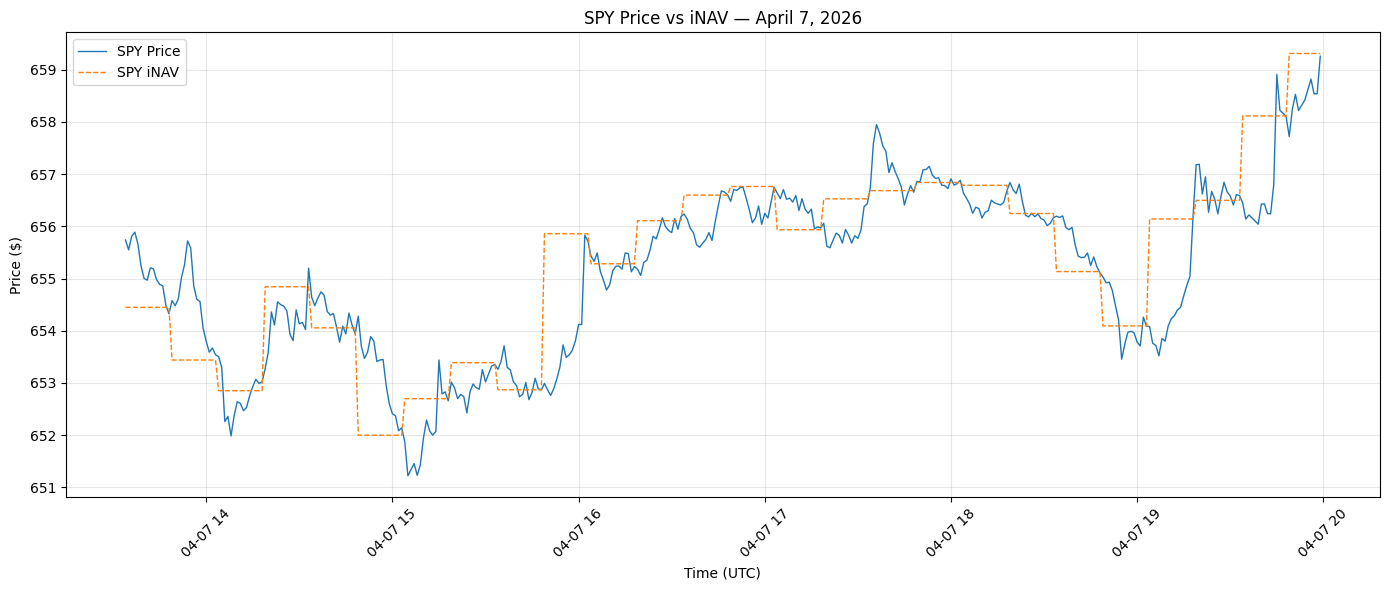

In [81]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(combined_SPY.index, combined_SPY["SPY_Price"], label="SPY Price", linewidth=1)
ax.plot(combined_SPY.index, combined_SPY["SPY_iNAV"], label="SPY iNAV", linewidth=1, linestyle="--")

ax.set_title("SPY Price vs iNAV — April 7, 2026")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Price ($)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

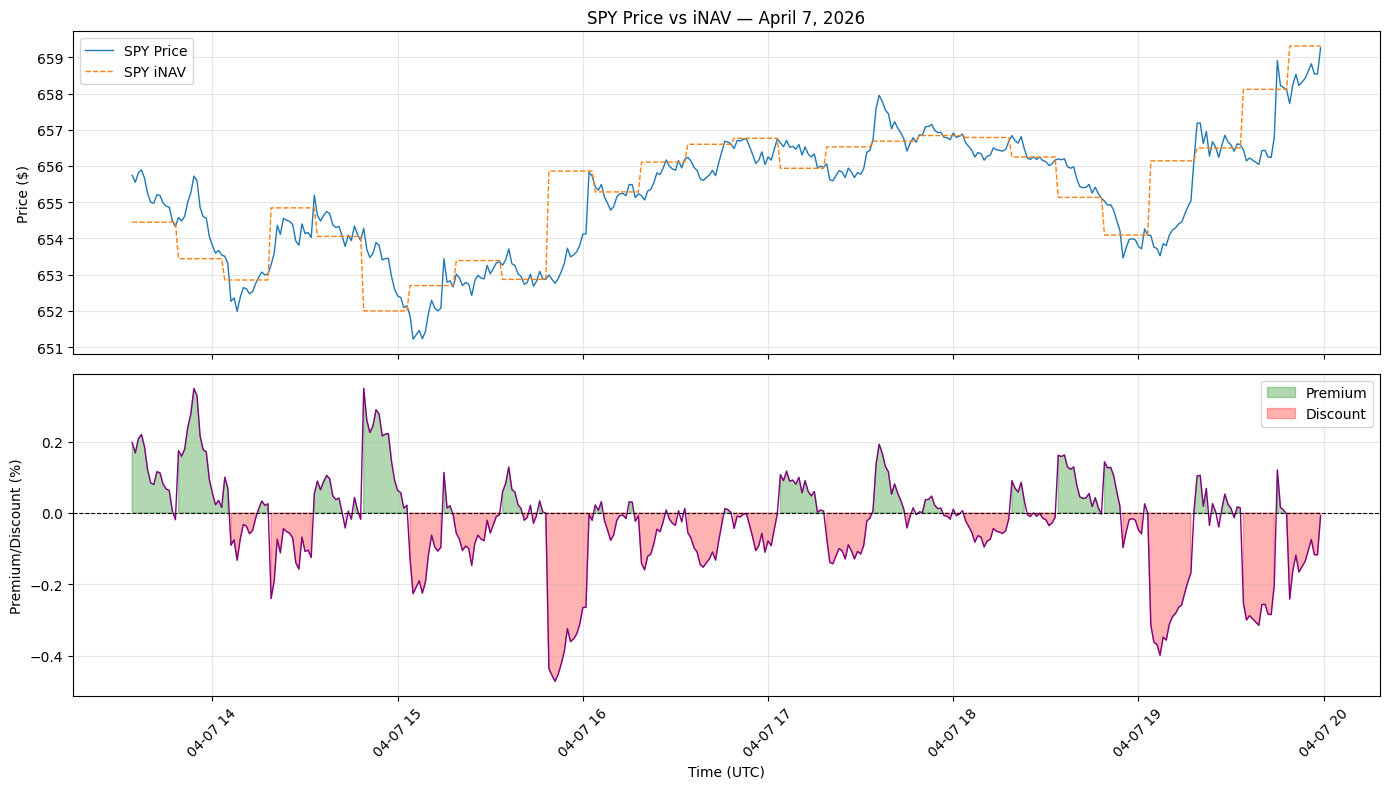

In [82]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel — price vs iNAV
ax1.plot(combined_SPY.index, combined_SPY["SPY_Price"], label="SPY Price", linewidth=1)
ax1.plot(combined_SPY.index, combined_SPY["SPY_iNAV"], label="SPY iNAV", linewidth=1, linestyle="--")
ax1.set_title("SPY Price vs iNAV — April 7, 2026")
ax1.set_ylabel("Price ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom panel — premium/discount
ax2.plot(combined_SPY.index, combined_SPY["Premium_Discount"], color="purple", linewidth=1)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.fill_between(combined_SPY.index, combined_SPY["Premium_Discount"], 0,
                 where=combined_SPY["Premium_Discount"] > 0, color="green", alpha=0.3, label="Premium")
ax2.fill_between(combined_SPY.index, combined_SPY["Premium_Discount"], 0,
                 where=combined_SPY["Premium_Discount"] < 0, color="red", alpha=0.3, label="Discount")
ax2.set_ylabel("Premium/Discount (%)")
ax2.set_xlabel("Time (UTC)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()